<a href="https://colab.research.google.com/github/AnilVemareddy/AnilVemareddy/blob/main/M2_AST_01_Model_Building_using_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
## Assignment-1: Model Building using PyTorch

## Learning Objectives

At the end of the experiment, you will be able to

* load and visualize the MNIST dataset
* understand & build different components of Model Class in PyTorch
* understand & build the train and test loop in PyTorch
* train the model '*Handwritten Digit Recognition*' and observe the accuracy

<h2><b>Handwritten Digit Recognition</b></h2>
<b> Problem Statement: </b> <br>
The goal of this exoeriment is to create a model that will be able to recognize and determine the handwritten digits from its image by using ML/DL techniques and observe the performance difference between various techniques. <br>
We use MNIST dataset for this task.

**MNIST Dataset**

The MNIST dataset (Modified National Institute of Standards and Technology database) is **a large database of handwritten digits** that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning. The MNIST database contains 60,000 training images and 10,000 testing images. Each image is a 28 by 28 pixel square (784 pixels total)

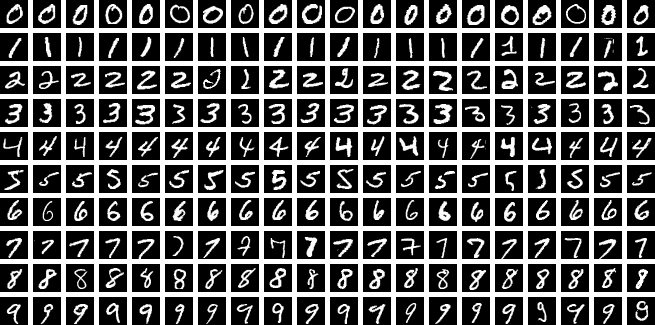

### Setup Steps:

In [4]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "2510561" #@param {type:"string"}

In [5]:
#@title Please enter your password (your registered phone number) to continue: { run: "auto", display-mode: "form" }
password = "9989165970" #@param {type:"string"}

In [6]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython
from IPython.display import HTML, display

ipython = get_ipython()

notebook= "M2_AST_01_Model_Building_using_PyTorch" #name of the notebook

batchId = "IISC-AC-GENAI-02"


def print_message(message: str, color: str = "red"):
    display(HTML(f"<span style='color:{color};'>{message}</span>"))

def setup():
#  ipython.magic("sx pip3 install torch")

    from IPython.display import HTML, display
    display(HTML('<script src="https://dashboard.talentsprint.com/submissions/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(), "batch" : batchId}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print_message(r["err"])
        return None
      else:
        print_message("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook,
              "feedback_experiments_input" : Comments,
              "feedback_mentor_support": Mentor_support,
              "batch" : batchId
            }
      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iisc.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


# def getWalkthrough():
#   try:
#     if not Walkthrough:
#       raise NameError
#     else:
#       return Walkthrough
#   except NameError:
#     print ("Please answer Walkthrough Question")
#     return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")

Setup completed successfully


### Importing Required Library

In [7]:
# Import libraries
import torch
import numpy as np
from matplotlib import pyplot as plt
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
import torch.nn as nn
import torch.nn.functional as F
import time

print("All libraries are loaded")

All libraries are loaded


### Load the MNIST dataset

In [8]:
# how many samples per batch to load
batch_size = 20

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and test datasets
train_data = MNIST(root = './', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


In [10]:
print(len(train_data))

60000


In [11]:
train_data, val_data = torch.utils.data.random_split(train_data, [50000, 10000])

test_data = MNIST(root = './', train=False, download=True, transform=transform)

print("Training data length : ", len(train_data))
print("Validation data length : ", len(val_data))
print("Test data length : ", len(test_data))

Training data length :  50000
Validation data length :  10000
Test data length :  10000


### Data Loader

In [12]:
# Create a DataLoader for the training dataset
# DataLoader loads the dataset in batches during training
# batch_size determines how many samples are processed in one batch
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)

print("Training data created")
print("Train-Data length : ", len(train_data))


# Create a DataLoader for the validation dataset
# Validation data is used to evaluate the model during training
# It helps monitor model performance and detect overfitting
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size)

print("Validation data created")
print("Validation-Data length : ", len(val_data))


# Create a DataLoader for the test dataset
# Test data is used after training to measure the final performance of the model
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)

print("Test data created")
print("Test-Data length : ", len(test_data))

Training data created
Train-Data length :  50000
Validation data created
Validation-Data length :  10000
Test data created
Test-Data length :  10000


### Visualize the dataset

Some of the training samples and their labels : 



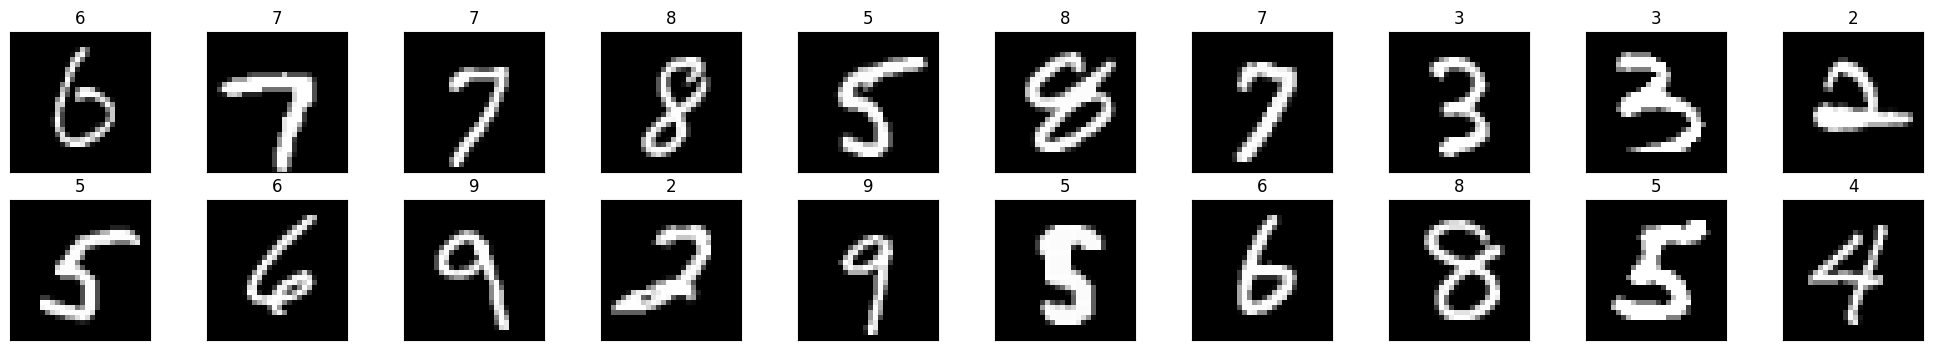

In [14]:
print("Some of the training samples and their labels : \n")

# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2,int(20/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

Pixel level View of one of the training sample 




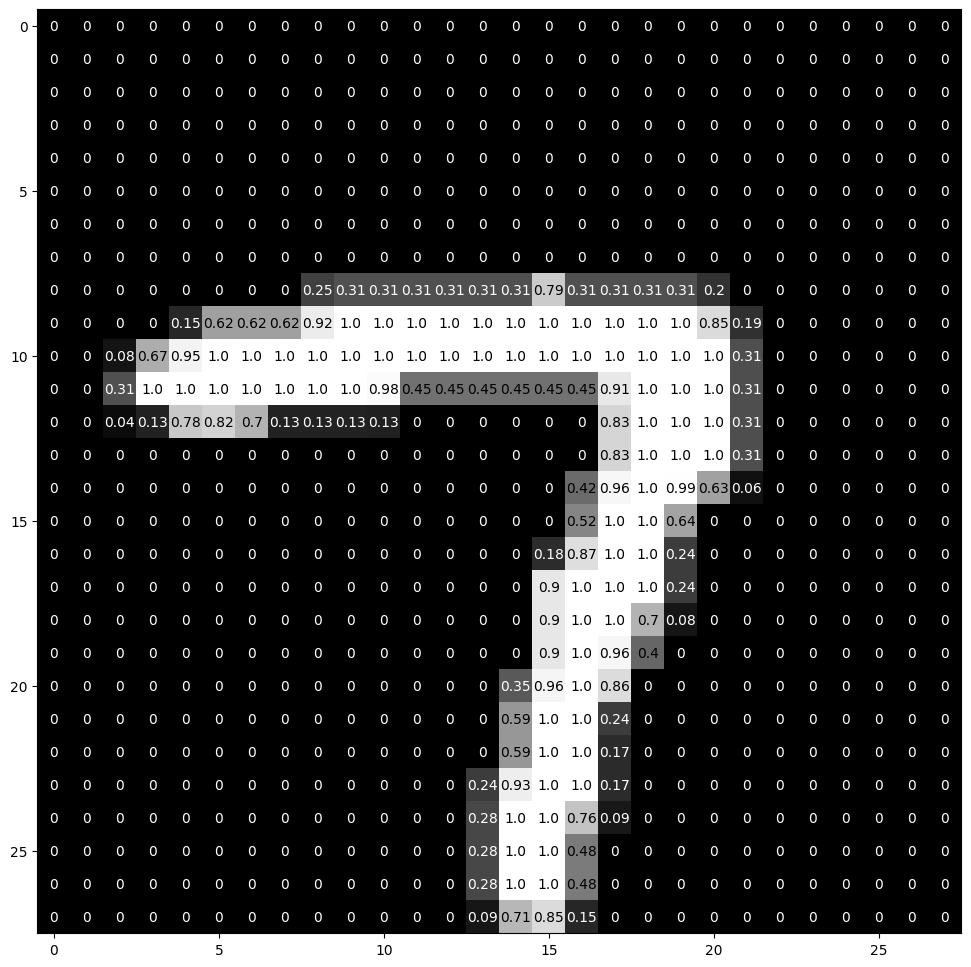

In [15]:
print ("Pixel level View of one of the training sample \n")
img = np.squeeze(images[1])
fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

print()

### **Initializing CUDA**

CUDA is used as an interface between our code and the GPU.

Normally, we run the code in the CPU. To run it in the GPU, we need CUDA. Check if CUDA is available:

In [16]:
# To test whether GPU instance is present in the system of not.
use_cuda = torch.cuda.is_available()
print('Using PyTorch version:', torch.__version__, 'CUDA:', use_cuda)

Using PyTorch version: 2.10.0+cu128 CUDA: True


If it's False, then we run the program on CPU. If it's True, then we run the program on GPU.

Let us initialize some GPU-related variables:

In [17]:
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

### **Build Model**

In [18]:
## Define the NN architecture

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 512)       # linear layer (n_hidden -> hidden_2)
        self.fc3 = nn.Linear(512, 10)        # linear layer (n_hidden -> 10)
        #self.dropout = nn.Dropout(0.2)       # dropout layer (p=0.2) # dropout prevents overfitting of data

    def forward(self, x):
        # flatten image input
        x = x.view(-1, 28 * 28)
        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x)) # F.relu
        return x

# initialize the NN
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


In [19]:
from torchsummary import summary

In [21]:
summary(model, input_size=(1,784), batch_size=-1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]         401,920
            Linear-2                  [-1, 512]         262,656
            Linear-3                   [-1, 10]           5,130
Total params: 669,706
Trainable params: 669,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.55
Estimated Total Size (MB): 2.57
----------------------------------------------------------------


### Specify loss and optimization functions

In [20]:
## Specify loss and optimization functions

# specify loss function
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(criterion, optimizer)

CrossEntropyLoss() SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### **Train Model**

In [22]:
# number of epochs to train the model
n_epochs = 20  # suggest training between 20-50 epochs

model.train() # prep model for training

for epoch in range(n_epochs):

    start = time.time()

    train_loss = 0.0                    # Initialize training, val loss
    val_loss=0.0

    ###################
    # Train the Model #
    ###################
    for data, target in train_loader:
        data=data.to(device)
        target=target.to(device)
        optimizer.zero_grad()            # clear the gradients of all optimized variables
        output = model(data)             # forward pass: compute predicted outputs by passing inputs to the model
        loss = criterion(output, target) # calculate the loss
        loss.backward()                  # backward pass: compute gradient of the loss with respect to model parameters
        optimizer.step()                 # perform a single optimization step (parameter update)
        train_loss += loss.item()*data.size(0)  # update running training loss

    for data, target in val_loader:
        data=data.to(device)
        target=target.to(device)
        output = model(data)                  # forward pass: compute predicted outputs by passing inputs to the model
        loss = criterion(output, target)      # calculate the loss
        val_loss += loss.item()*data.size(0)  # update running training loss

    # print training statistics
    train_loss = train_loss/len(train_loader.dataset)  # calculate average loss over an epoch"""
    val_loss = val_loss/len(val_loader.dataset)        # Validation loss

    end = time.time()
    total_time = end - start

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f} \t Time: {:.4f} sec'.format( epoch+1, train_loss, val_loss, total_time))

print("Training is done\n")

Epoch: 1 	Training Loss: 1.212625 	Validation Loss: 0.770774 	 Time: 10.3018 sec
Epoch: 2 	Training Loss: 0.730698 	Validation Loss: 0.699167 	 Time: 10.0918 sec
Epoch: 3 	Training Loss: 0.683913 	Validation Loss: 0.659029 	 Time: 10.0685 sec
Epoch: 4 	Training Loss: 0.652451 	Validation Loss: 0.632208 	 Time: 9.6102 sec
Epoch: 5 	Training Loss: 0.626874 	Validation Loss: 0.611259 	 Time: 9.8517 sec
Epoch: 6 	Training Loss: 0.605361 	Validation Loss: 0.594456 	 Time: 10.0916 sec
Epoch: 7 	Training Loss: 0.586823 	Validation Loss: 0.579933 	 Time: 9.9358 sec
Epoch: 8 	Training Loss: 0.570979 	Validation Loss: 0.567299 	 Time: 10.1388 sec
Epoch: 9 	Training Loss: 0.557508 	Validation Loss: 0.558879 	 Time: 9.8677 sec
Epoch: 10 	Training Loss: 0.546103 	Validation Loss: 0.550168 	 Time: 9.5621 sec
Epoch: 11 	Training Loss: 0.536257 	Validation Loss: 0.542647 	 Time: 9.9548 sec
Epoch: 12 	Training Loss: 0.527577 	Validation Loss: 0.536191 	 Time: 10.0688 sec
Epoch: 13 	Training Loss: 0.520

### **Test the Model**

In [ ]:
# Testing the  model
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval() # prepare model for *evaluation*

for data, target in test_loader:
    data = data.to(device)
    target = target.to(device)
    output = model(data)                            # forward pass: compute predicted outputs by passing inputs to the model
    loss = criterion(output, target)                # calculate the loss
    test_loss += loss.item()*data.size(0)           # update test loss
    _, pred = torch.max(output, 1)                  # convert output probabilities to predicted class
    correct = np.squeeze(pred.eq(target.data.view_as(pred)))        # compare predictions to true label

    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# calculate and print avg test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of Class label - %1s: %2d%% (%2d/%2d)' % (
            str(i), 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of Class label - %1s: N/A (no training examples)' % (i))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))
print()

In [ ]:
# obtain one batch of test images

print("Test Images and their predicted labels : \n")

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# get sample outputs
output = model(images)

_, preds = torch.max(output, 1)  # convert output probabilities to predicted class
images = images.cpu()        # prep images for display

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

### Please answer the questions below to complete the experiment:




In [23]:
#@title In the context of training a model, what does an epoch represent? { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "One complete pass through the entire training dataset" #@param ["", "A single update of model weights using one training example", "One complete pass through the entire training dataset", "The total number of layers in the neural network", "The number of parameters in the model"]

In [24]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "Good, But Not Challenging for me" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [44]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "the sample data" #@param {type:"string"}


In [25]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "Yes" #@param ["","Yes", "No"]


In [26]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [27]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "Very Useful" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [45]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

Your submission is successful.
Ref Id: 308
Date of submission:  07 Mar 2026
Time of submission:  15:03:58
View your submissions: https://learn-iisc.talentsprint.com/notebook_submissions


---

<center>
$END$
</center>

---